# LOS<8 Prediction — XGBoost Model (Lab-Only Dataset)

Simple end-to-end pipeline: load data, quick EDA charts, train an XGBoost classifier, and evaluate it.

This version is adapted for a dataset containing **only lab-value features** (no demographic/admission fields):
`ALT, Amylase, Bilirubin, Calcium, Creatinine, Creatine Kinase, Hematocrit, Lactate, Lipase, MCH, MCHC, MCV, PT, WBC`

**Target:** `LOS<8` — 1 = length of stay < 8 days, 0 = length of stay ≥ 8 days.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load data

In [2]:
# Update this path to point to your new dataset (xlsx or csv)
data_path = '../sample_datasets/MIMIC3LAB.xlsx'

if data_path.lower().endswith('.csv'):
    df = pd.read_csv(data_path)
else:
    df = pd.read_excel(data_path)

df.head()


,ALT,Amylase,Bilirubin,Calcium,Creatinine,Creatine Kinase,Hematocrit,Lactate,Lipase,MCH,MCHC,MCV,PT,WBC,LOS<8
0,51.362205,12.512821,2.224000,9.796759,0.539744,2.00,30.020576,1.819231,21.393443,28.386829,31.448293,90.341463,15.324818,12.475498,1
1,264.362319,216.567568,2.167742,8.506322,2.612155,5.00,27.698305,2.891209,183.236842,28.412414,32.009655,88.896552,17.408333,11.398621,1
2,43.333333,151.105263,0.551613,8.226882,1.147525,4.25,34.066667,2.997143,88.888889,28.752381,32.944048,87.452381,15.692593,10.053488,1
3,148.976191,83.650000,6.873684,8.785606,1.710714,39.00,25.452033,2.218947,471.034483,32.902703,34.009910,96.585586,17.782353,16.551304,1
4,43.750000,261.033333,2.317544,9.590341,1.515000,4.00,25.894413,1.176984,123.629630,30.673333,32.324837,94.766667,14.141667,15.090190,1


## 2. Quick overview

In [6]:
print('Shape:', df.shape)
print('\nMissing values per column:\n', df.isnull().sum().sum())
print('\nTarget class balance:\n', df['LOS<8'].value_counts(normalize=True))
df.describe()

Shape: (943, 15)

Missing values per column:
 0

Target class balance:
 LOS<8
0    0.661718
1    0.338282
Name: proportion, dtype: float64


,ALT,Amylase,Bilirubin,Calcium,Creatinine,Creatine Kinase,Hematocrit,Lactate,Lipase,MCH,MCHC,MCV,PT,WBC,LOS<8
count,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000
mean,142.844565,238.403401,2.354045,8.264482,1.548510,10.047141,30.880280,2.233893,404.417112,30.385114,33.441535,90.929214,15.404130,12.575436,0.338282
std,398.045125,245.048979,4.442952,0.611071,1.600936,16.939896,4.110468,1.716004,548.523533,2.498280,1.279638,6.676160,4.137589,5.990893,0.473376
min,3.000000,8.000000,0.100000,5.762500,0.221429,1.000000,17.350000,0.600000,5.250000,19.100000,26.588889,63.375000,9.350000,0.335714,0.000000
25%,23.000000,96.111111,0.513333,7.888194,0.680000,4.083333,27.863782,1.357418,92.635417,29.132143,32.752778,87.065714,13.265476,8.555000,0.000000
50%,47.666667,167.500000,0.918519,8.226882,0.974390,9.475888,30.188235,1.800000,223.909091,30.406667,33.443478,90.388889,14.275000,11.800000,0.000000
75%,99.713235,286.166667,2.240000,8.592634,1.686477,9.729137,33.351667,2.497826,483.533333,31.896528,34.200000,94.716667,15.861429,15.318250,1.000000
max,5235.000000,2237.333333,48.366667,12.976667,13.350000,308.000000,46.872727,18.150000,6043.500000,40.000000,37.790000,121.875000,56.700000,61.111765,1.000000


## 3. Exploratory charts — feature relationships with LOS<8

A quick look at the target distribution and how each feature relates to it, for the report.

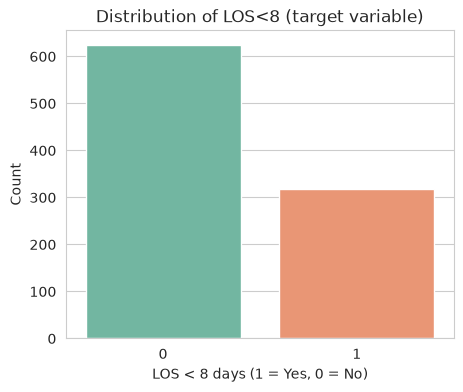

In [7]:
# Target distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='LOS<8', data=df, hue='LOS<8', palette='Set2', legend=False)
plt.title('Distribution of LOS<8 (target variable)')
plt.xlabel('LOS < 8 days (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

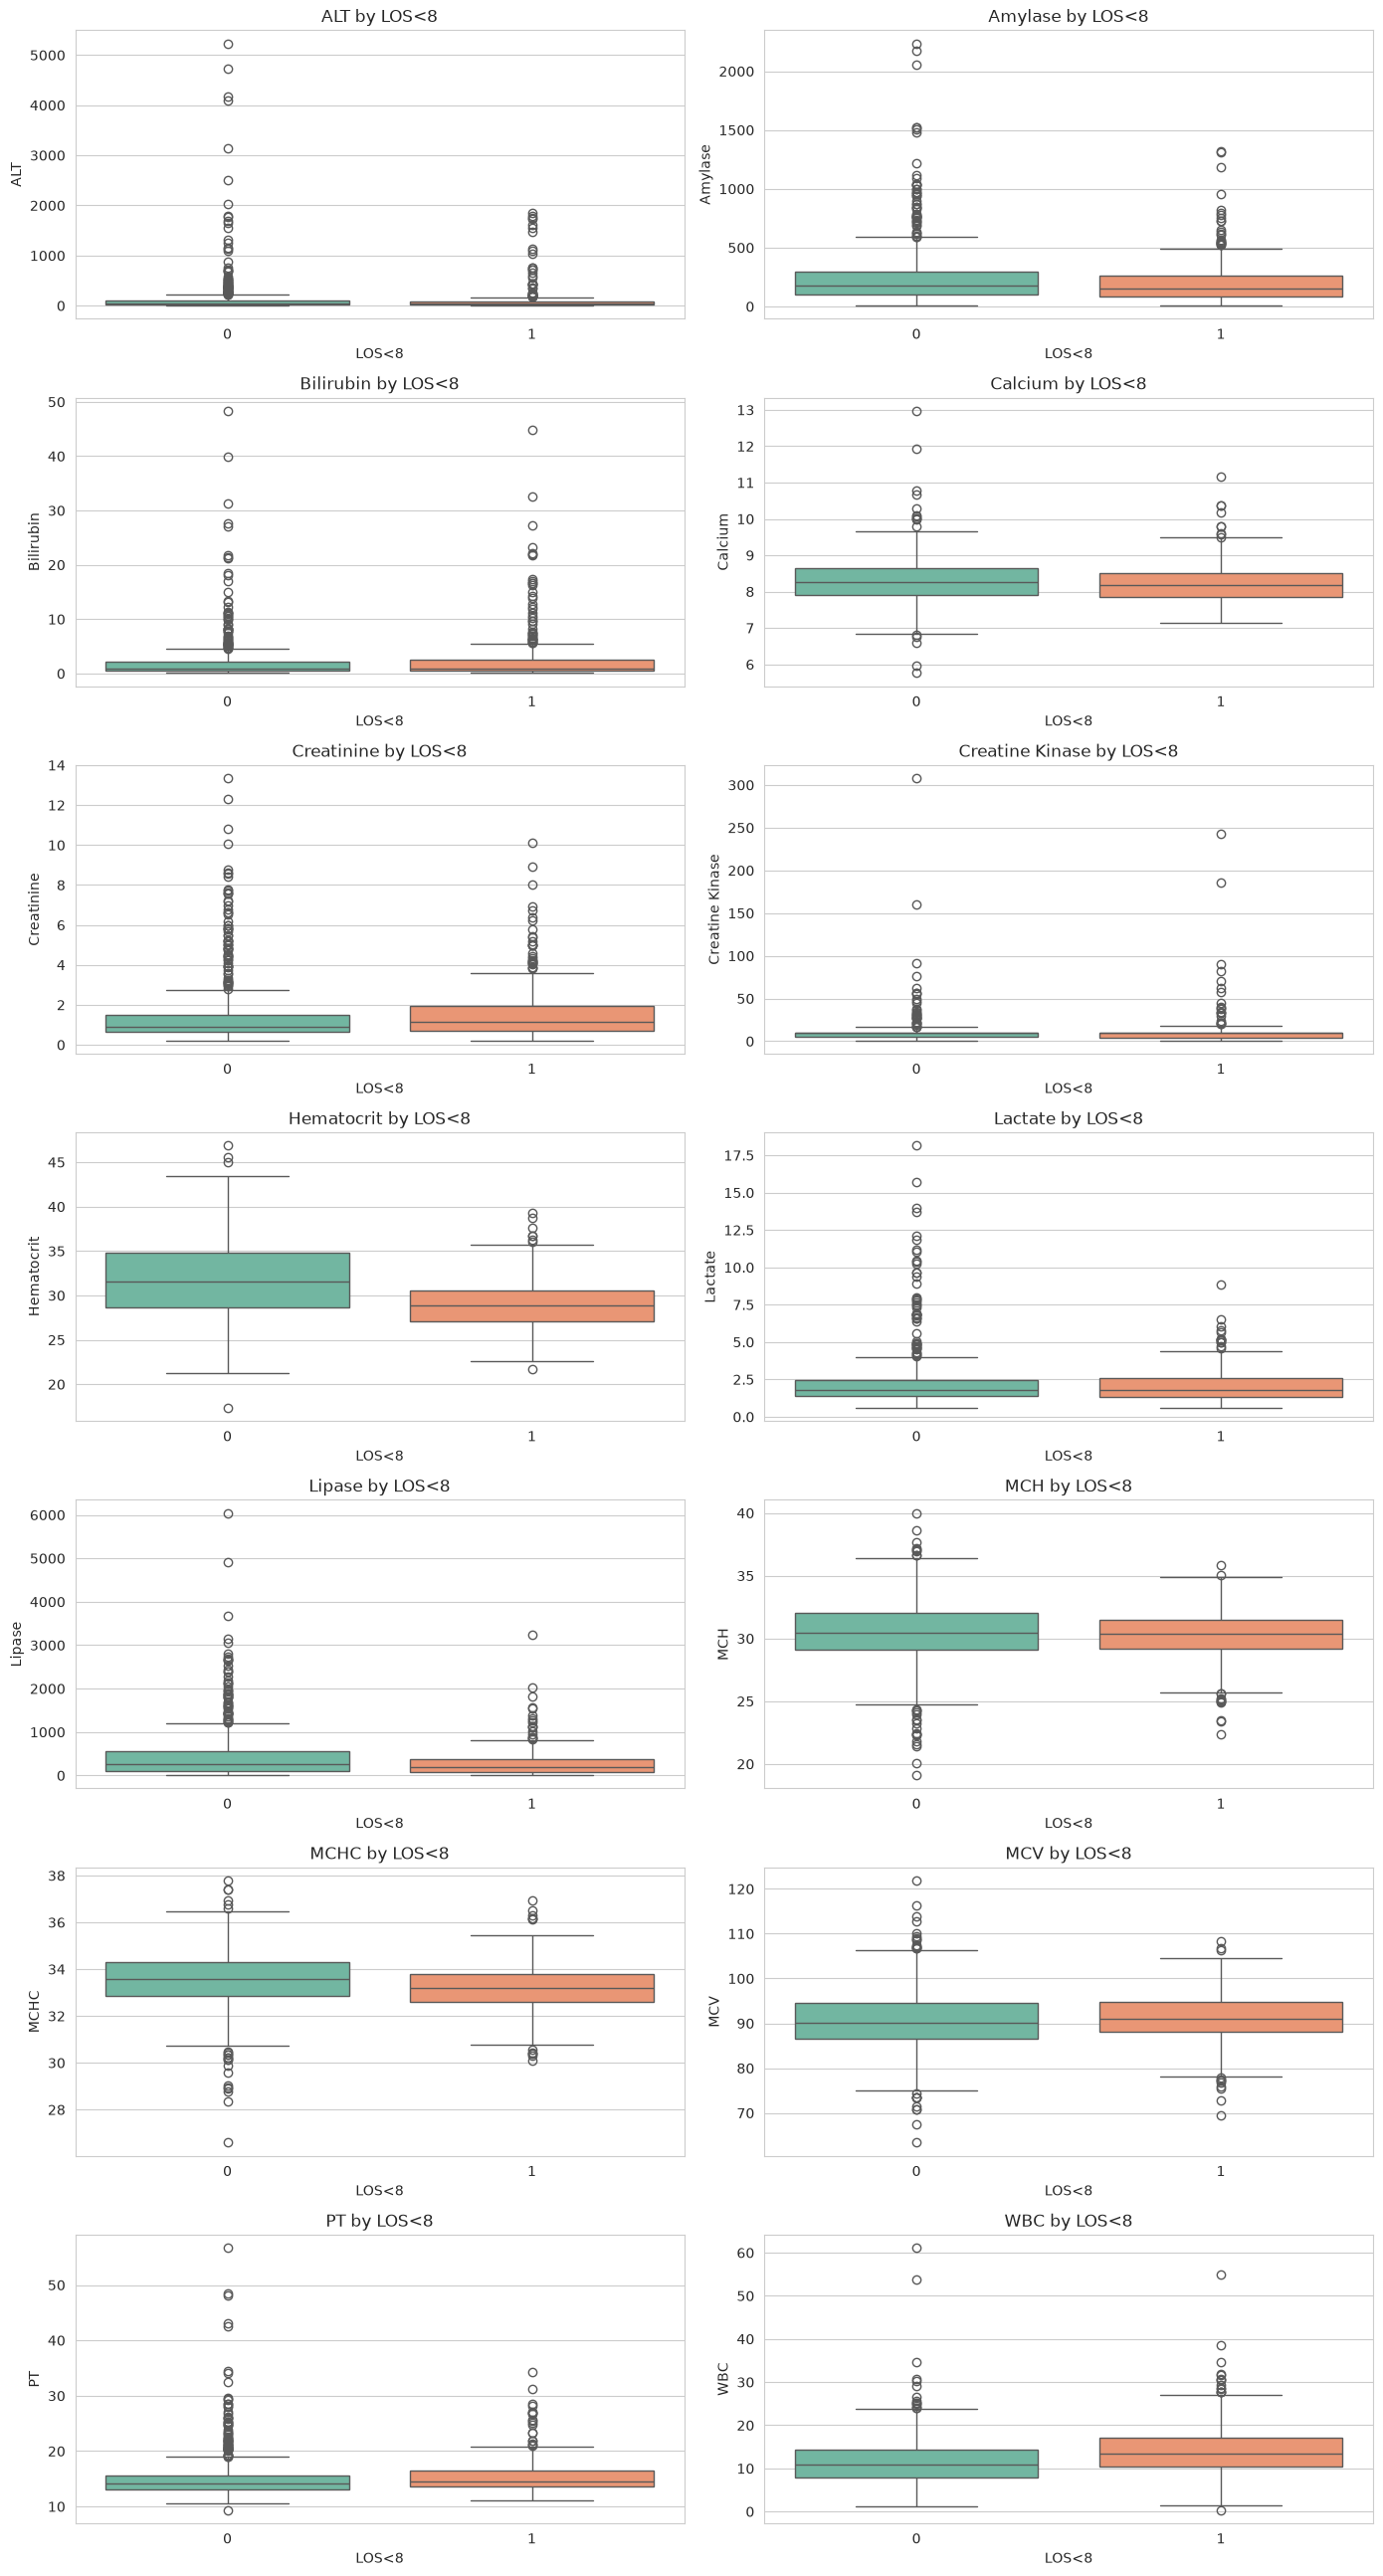

In [ ]:
# Lab features vs the label
numeric_cols = ['ALT', 'Amylase', 'Bilirubin', 'Calcium', 'Creatinine',
                'Creatine Kinase', 'Hematocrit', 'Lactate', 'Lipase',
                'MCH', 'MCHC', 'MCV', 'PT', 'WBC']

fig, axes = plt.subplots(7, 2, figsize=(14, 26))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='LOS<8', y=col, data=df, ax=axes[i], hue='LOS<8', palette='Set2', legend=False)
    axes[i].set_title(f'{col} by LOS<8')
plt.tight_layout()
plt.show()


In [9]:
# This dataset has no categorical/demographic columns (Gender, Insurance, race, etc.),
# so that comparison is skipped here.


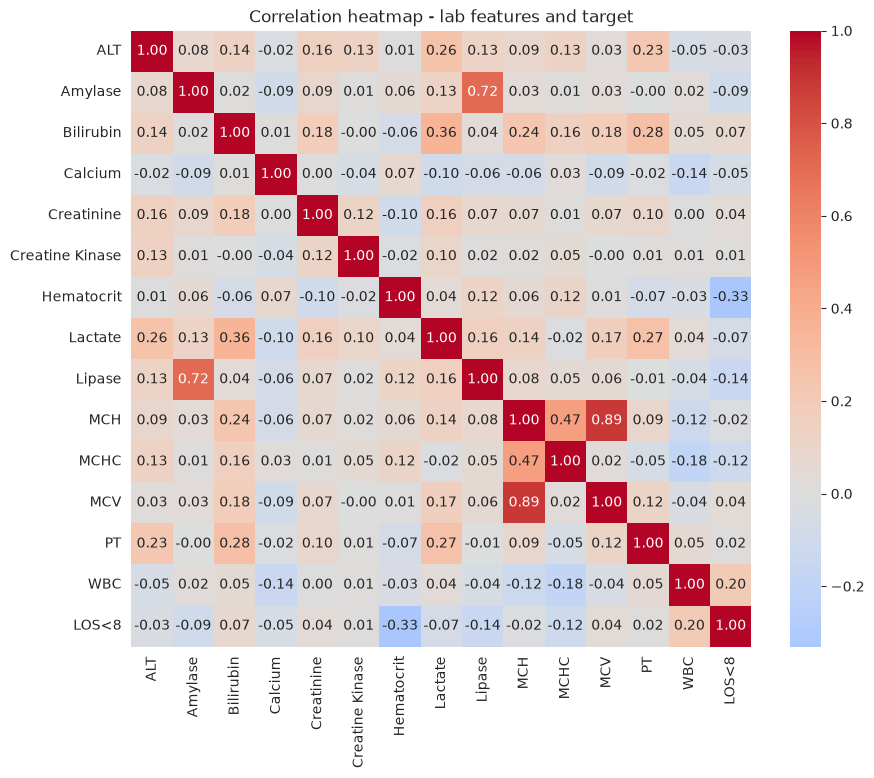

In [10]:
# Correlation among lab features and the target
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['LOS<8']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap - lab features and target')
plt.show()


## 4. Prepare data for modeling

In [11]:
# No categorical columns in this dataset - use lab features directly
X = df.drop(columns=['LOS<8'])
y = df['LOS<8']

print('Feature matrix shape:', X.shape)


Feature matrix shape: (943, 14)


## 5. Train/test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (754, 14)  Test shape: (189, 14)


## 6. Train the XGBoost model

In [13]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    importance_type='gain',
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 7. Evaluate the model

In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('\nClassification report:\n', classification_report(y_test, y_pred))

Accuracy: 0.746031746031746
ROC-AUC: 0.83275

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       125
           1       0.66      0.52      0.58        64

    accuracy                           0.75       189
   macro avg       0.72      0.69      0.70       189
weighted avg       0.74      0.75      0.74       189



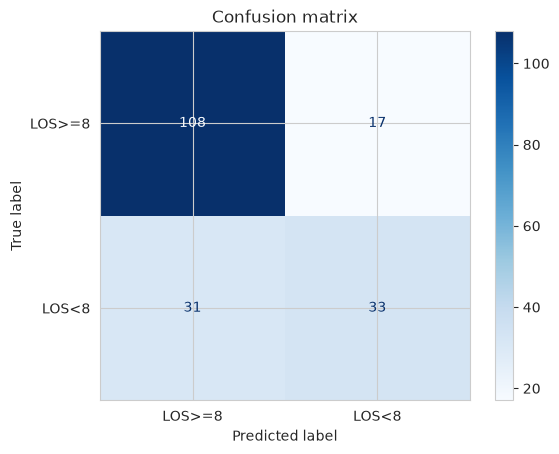

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOS>=8', 'LOS<8'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

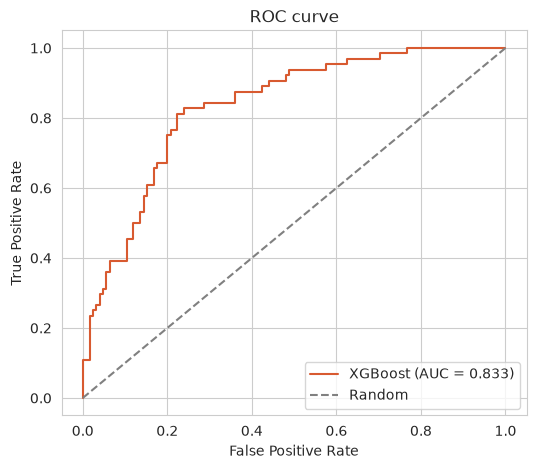

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})', color='#D85A30')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()

## 8. Feature importance

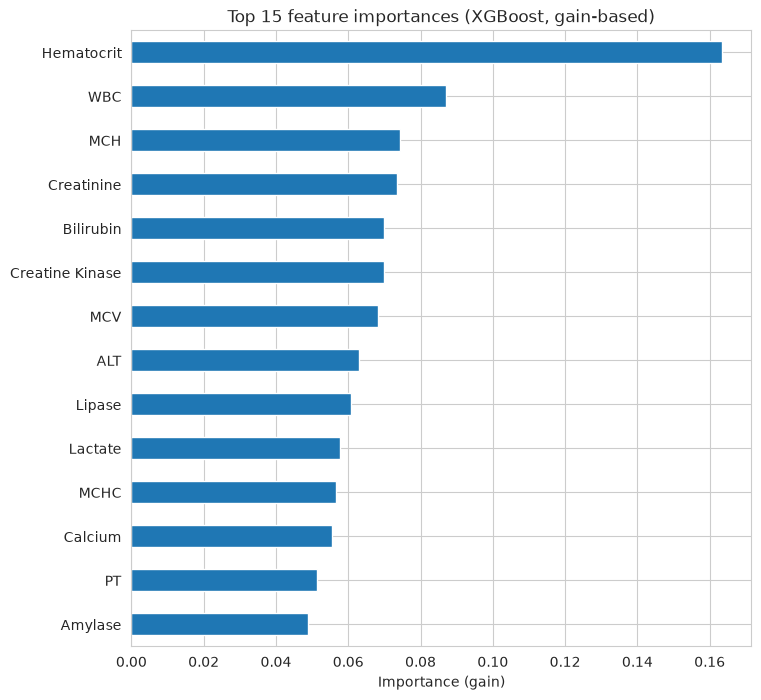

In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (XGBoost, gain-based)')
plt.xlabel('Importance (gain)')
plt.show()

## 9. Results summary (for your report)

In [18]:
print('=== Model Results Summary ===')
print('Model: XGBoost Classifier')
print(f'Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

report_dict = classification_report(y_test, y_pred, output_dict=True)
print(f"Precision (LOS<8=1): {report_dict['1']['precision']:.3f}")
print(f"Recall (LOS<8=1): {report_dict['1']['recall']:.3f}")
print(f"F1-score (LOS<8=1): {report_dict['1']['f1-score']:.3f}")

=== Model Results Summary ===
Model: XGBoost Classifier
Train samples: 754, Test samples: 189
Accuracy: 0.746
ROC-AUC: 0.833
Precision (LOS<8=1): 0.660
Recall (LOS<8=1): 0.516
F1-score (LOS<8=1): 0.579
